### STEP 1 - Business Understanding

This project aims to build a machine learning model to predict housing prices in California so as to help real estate companies price properties.
This is a regression task as the price is a continuous variable i.e numeric. If the output was categorical then it wouls have been a classification task.

### STEP 2 - Load the Libraries

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data=fetch_california_housing()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['price']=data.target

df.head(100)


What is happening here?

We load the dataset from sklearn.

Convert it into a pandas DataFrame.

Add the target column (Price).

### STEP 3 — EDA (Exploratory Data Analysis)

EDA helps you:

Understand patterns

Detect errors

Detect outliers

Check distributions

Check relationships

Decide preprocessing steps

3.1 Check Structure

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


3.2 Summary Statistics

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


This helps detect:

Extreme values

Skewed data

Check for missing values

In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

3.4 Distribution of Target Variable

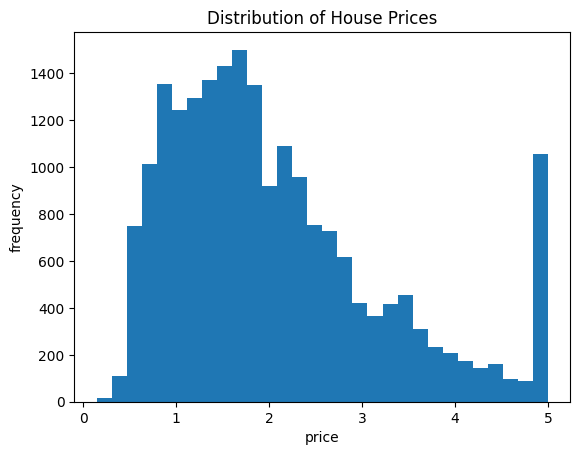

In [12]:
import matplotlib.pyplot as plt

plt.hist(df['price'],bins=30)
plt.xlabel('price')
plt.ylabel('frequency')
plt.title("Distribution of House Prices")

plt.show()

This is a positively skewed distribution (also called right-skewed distribution).

How We Know It’s Right-Skewed

From the histogram,Most house prices are concentrated on the left/middle side.There is a long tail extending to the right. A few houses have very high prices compared to the majority. That long right tail = positive skew

What It Tells Us
Most houses are in the lower-to-mid price range.Fewer houses are very expensive.
There are outliers or high-value properties pulling the distribution to the right
Mean price is likely higher than the median because of those expensive houses

3.4.1 Calculating skewness

In [15]:
skewness=df['price'].skew()

print("Skewness before log:", skewness)

Skewness before log: 0.9777632739098335


How to Interpret Skewness

If skewness ≈ 0 → Normal distribution
If skewness > 0 → Right-skewed
If skewness < 0 → Left-skewed
If skewness > 1 → Highly skewed

Our graph above is right-skewed

3.4.2 Apply Log Transformation

When your target variable (like price) is right-skewed, we apply a log transformation to:

Reduce skewness

Reduce impact of extreme values

Make distribution more normal

Improve Linear Regression performance

In [17]:
import numpy as np

df['price_log']=np.log1p(df['price'])

## We use log1p() instead of log() because log(0) = undefined, log1p(x) = log(1 + x) → safer

3.4.3 Calculate Skewness after log transformation

In [18]:
skewness=df['price_log'].skew()

print("Skewness after log:", skewness)

Skewness after log: 0.27593905091711324


3.4.4 Plotting distribution After Log

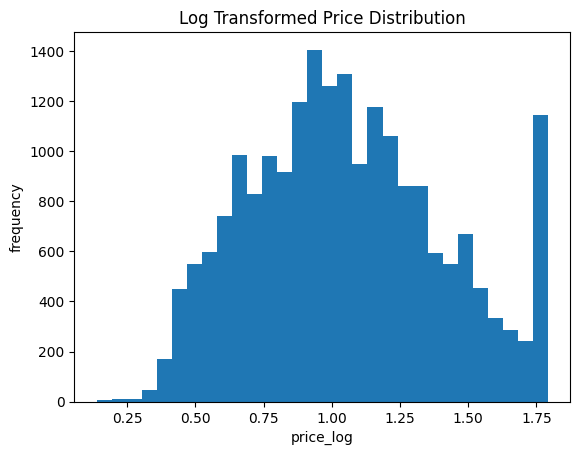

In [21]:
plt.hist(df['price_log'],bins=30)
plt.xlabel('price_log')
plt.ylabel('frequency')
plt.title('Log Transformed Price Distribution')

plt.show()

You’ll notice:

✔ The right tail becomes shorter
✔ Distribution looks more symmetric

How This Affects Linear Regression

This is VERY important for interviews.

Linear Regression assumes:

Linearity

Normal distribution of errors

Homoscedasticity (constant variance)

3.5 Feature Distributions

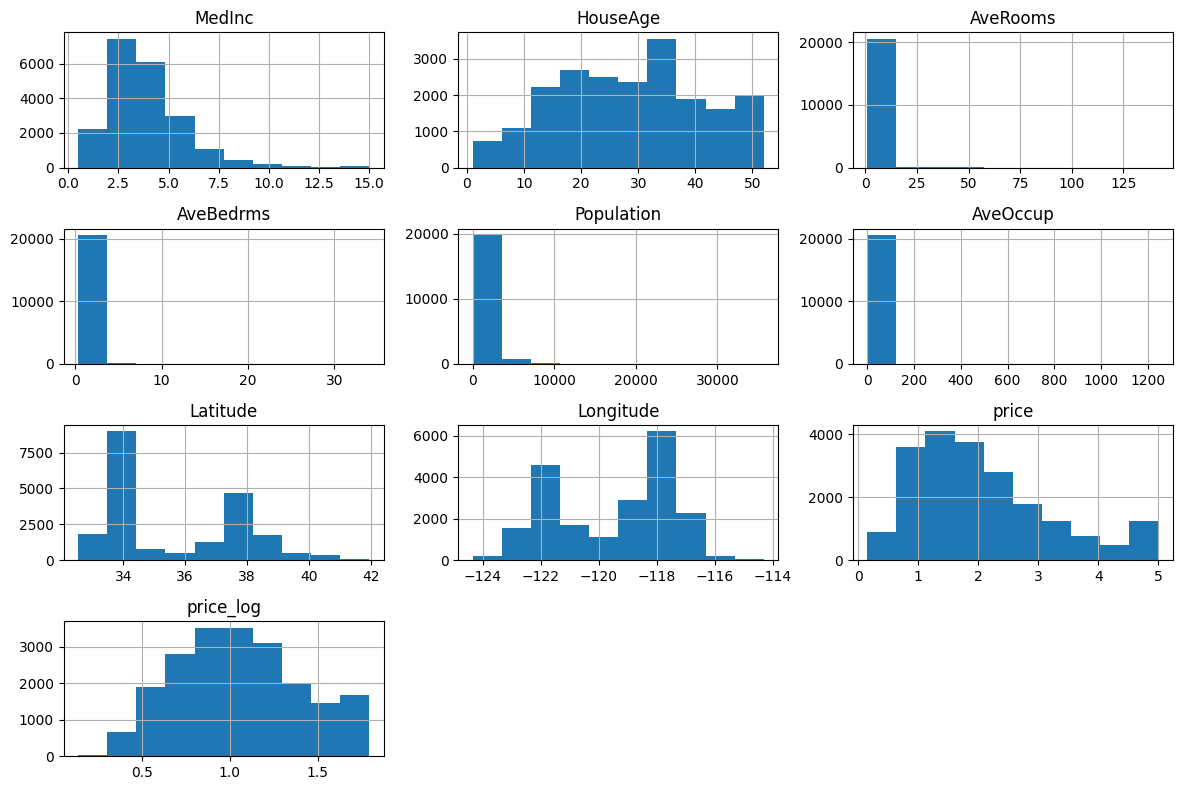

In [24]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Why?
To see:

Are features skewed?

Are there extreme outliers?

Are they on different scales?

This explains why scaling is needed.

3.6 Correlation Matrix

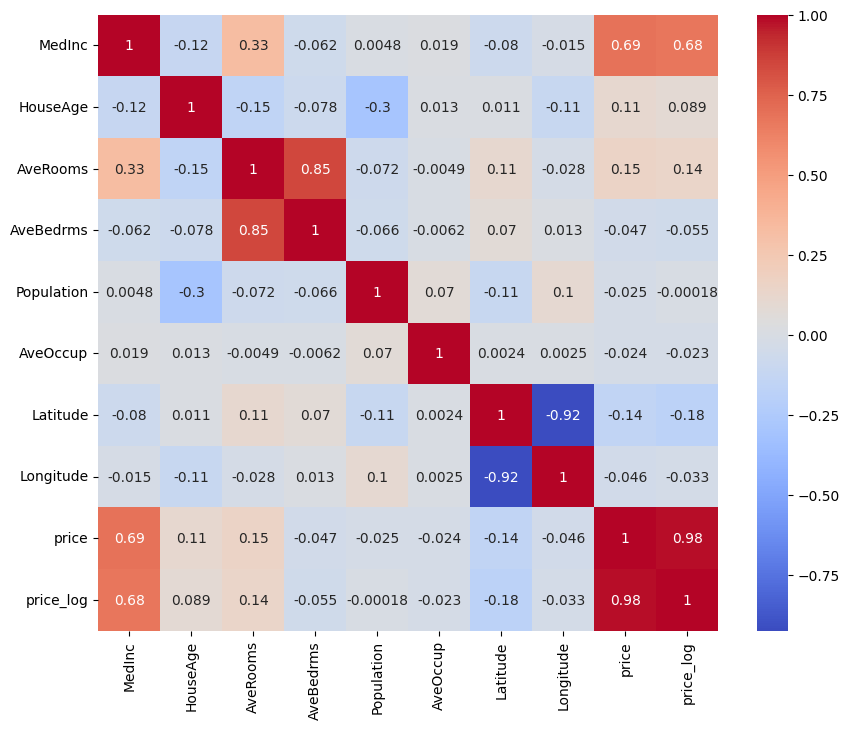

In [25]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Why?

This shows:

Which features affect Price most.

Multicollinearity (features highly correlated with each other).

Example:
If MedInc has strong positive correlation with Price → strong predictor.


3.7 Scatter Plots (Relationship Check)

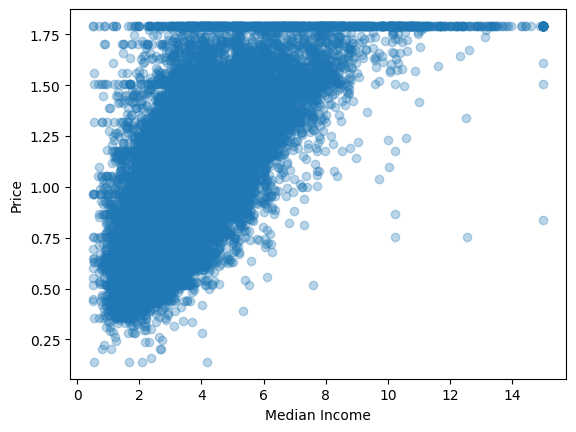

In [29]:
import seaborn as sns

plt.scatter(df["MedInc"], df["price_log"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Price")
plt.show()

Why?

To visually see:

Is relationship linear?

Is it curved?

Is it random?

If relationship is non-linear → tree models may perform better than linear regression.

There is a strong positive linear relationship between median income and house price. However, the variance increases at higher income levels and the price appears capped at the upper bound, which may introduce heteroscedasticity(i.e when the variance of residuals (error terms) is not constant across all levels of the independent variables) and bias in a linear regression model.

### STEP 4 — Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X=df.drop('price_log',axis=1)
y=df['price_log']

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Why split?

Because:

If you train and test on the same data:

Model will memorize → looks perfect → fails in real life.

80% training
20% testing

This simulates real-world unseen data.

### STEP 5 — Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)#fit-learns the statistics of the data,stores them internally, transform-applies the statistics
x_test_scaled=scaler.transform(x_test)# does not learn anything new from the data, it just applies the statistics on=btained from the training data set

We fit the scaler on training data to learn the feature distribution, then apply the same transformation to the test set to prevent data leakage and ensure the model generalizes to unseen data.

### STEP 6 — Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_pred_lr=lr.predict(x_test_scaled)

What it does:

Fits a straight hyperplane in multi-dimensional space.

It assumes:

Linear relationship

No strong multicollinearity

Homoscedasticity

### STEP 7 — Evaluation

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.05226837645567948
RMSE: 0.065423218737359
R2: 0.96604213860014


What they mean:

MAE → Average error
RMSE → Penalizes large errors
R² → % of variance explained

### STEP 8 — Ridge & Lasso

8.1 Ridge Regression (L2 Penalty)

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(x_train_scaled, y_train)

y_pred_ridge = ridge.predict(x_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Results:")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Ridge Results:
MAE: 0.05227064821457942
RMSE: 0.06542364435887757
R2: 0.9660416967617887


8.2 Lasso (L1 Penalty)

In [44]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(x_train_scaled, y_train)

y_pred_lasso = lasso.predict(x_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Results:")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

Lasso Results:
MAE: 0.10181085421078752
RMSE: 0.12369431615069364
R2: 0.8786119303549933


When To Use Ridge vs Lasso
Situation	Use
Many correlated features -	Ridge

Want feature selection -Lasso

Very high dimensional data -Lasso

Stable performance- Ridge

### STEP 9 — Decision Tree

What Is It?

Instead of drawing a straight line:

It splits data like:

IF MedInc > 4 → go left
ELSE → go right

It builds a tree of rules.

Why It’s Powerful:

Handles non-linearity

No scaling required

Handles outliers better

Weakness:

Overfits easily

Very unstable

In [45]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)

Decision Tree Results:
MAE: 0.00010739840941159564
RMSE: 0.001711065757303194
R2: 0.9999767721016148


### STEP 10 — Random Forest Regressor

What Is Random Forest?

Instead of one tree:

It builds 100+ trees.

Each tree:

Sees different data

Sees different features

Final prediction = average of all trees.

Why It’s Powerful:

Reduces overfitting

Handles non-linear patterns

Works great out-of-the-box

Minimal preprocessing

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results:
MAE: 6.98760739523866e-05
RMSE: 0.0007387134486172227
R2: 0.9999956705918678


### STEP 11 — Compare All Models

In [47]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Decision Tree", "Random Forest"],
    "MAE": [mae, mae_ridge, mae_lasso, mae_dt, mae_rf],
    "RMSE": [rmse, rmse_ridge, rmse_lasso, rmse_dt, rmse_rf],
    "R2": [r2, r2_ridge, r2_lasso, r2_dt, r2_rf]
})

print(results)

           Model       MAE      RMSE        R2
0         Linear  0.052268  0.065423  0.966042
1          Ridge  0.052271  0.065424  0.966042
2          Lasso  0.101811  0.123694  0.878612
3  Decision Tree  0.000107  0.001711  0.999977
4  Random Forest  0.000070  0.000739  0.999996


How To Choose Best Model

Look for:

Lowest RMSE

Highest R²

Small difference between train and test performance

Usually:
Random Forest wins.

### STEP 12 — Hyperparameter Tuning

Why?

Default settings are not always optimal.

We use:

Cross-validation

Multiple parameter combinations

Model: Random Forest

We tune:

n_estimators → number of trees

max_depth → depth of trees

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.9999937362575766


Use Best Model

In [51]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(x_test)

print("Final R2:", r2_score(y_test, y_pred_best))

Final R2: 0.9999946946122636


### STEP 13 — Feature Importance

Why?

So you can explain to stakeholders.

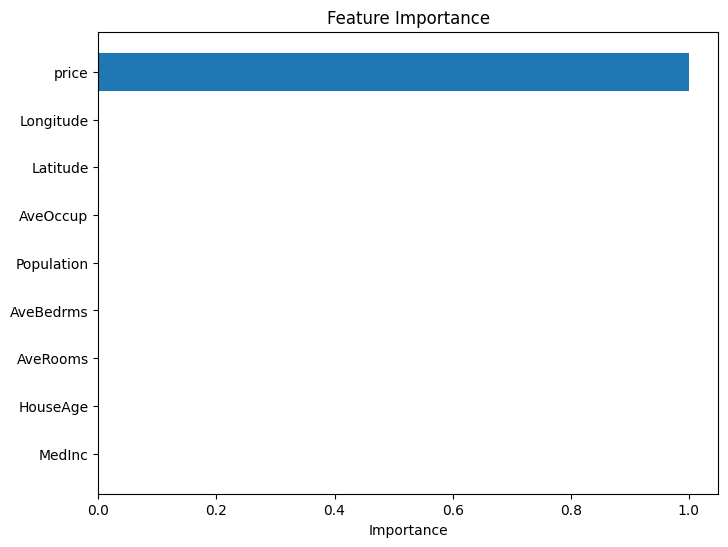

In [52]:
import matplotlib.pyplot as plt

importance = best_rf.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()